# Logistic Regression - Probabilities, Decision Boundaries, and Pipelines

<hr>

<center>
<div>
<img src="https://raw.githubusercontent.com/davi-moreira/2026Summer_predictive_analytics_purdue_MGMT474/main/notebooks/figures/mgmt_474_ai_logo_02-modified.png" width="200"/>
</div>
</center>

# <center><a class="tocSkip"></center>
# <center>QM47400 Predictive Analytics</center>
# <center>Professor: Davi Moreira </center>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/davi-moreira/2026Summer_predictive_analytics_purdue_MGMT474/blob/main/notebooks/nb06_logistic_pipelines_student.ipynb)

---

## Learning Objectives

By the end of this notebook, you will be able to:

1. Run the NB01 six-step EDA checklist adapted to classification (data types, missingness, descriptives, class balance, feature distributions by class, correlation-with-target)
2. Produce a stratified 60/20/20 train/val/test split with per-partition sanity checks
3. Fit logistic regression with preprocessing in a pipeline
4. Interpret probabilities vs classes (and why thresholds matter)
5. Choose an appropriate baseline for classification
6. Document the classification objective and error costs

---

> **📋 Participation Reminder:** This notebook contains **2 PAUSE-AND-DO exercises**. You are expected to complete all exercises before submitting your notebook.

---

## What is a Classification Problem?

<center>
<img src="https://raw.githubusercontent.com/davi-moreira/naive_bayes/main/figs/boxes.gif" width="500"/>
</center>

Classification involves categorizing data into predefined classes or groups based on their features.

---

## 💼 Why This Matters: From Prices to Probabilities

A new client arrives at your desk: the **State Health Department** wants a breast cancer screening tool. They have digitized cell measurements from fine-needle aspirates — 30 numeric features describing each cell nucleus (radius, texture, perimeter, area, smoothness...). The question is no longer "how much?" but "which category?" — malignant or benign.

This shift from predicting a number to predicting a class changes everything: the model, the metrics, the pipeline, and the stakes. A wrong house price estimate costs dollars; a wrong cancer diagnosis can cost a life.

> **Today's focus:** Building our first classification model with logistic regression, and constructing pipelines that handle the breast cancer dataset from raw features to probability predictions.

---

In [18]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, log_loss, confusion_matrix, classification_report
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.precision', 4)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
RANDOM_SEED = 474
np.random.seed(RANDOM_SEED)
print("✓ Setup complete!")

✓ Setup complete!


**Reading the output:**

The `Setup complete!` message confirms that all imports loaded. This notebook introduces the classification toolkit the Health Department project demands: `LogisticRegression` for probability-based diagnosis, `DummyClassifier` for the "predict everyone benign" baseline, and `confusion_matrix` plus `classification_report` for dissecting exactly which patients the model gets wrong. We also import the breast cancer dataset itself (`load_breast_cancer`) and a synthetic data generator (`make_classification`) for later experiments. The usual display settings and **RANDOM_SEED = 474** remain in effect.

**Why this matters:** Regression tools (MAE, RMSE, R-squared) are useless when the target is malignant vs. benign. Classification requires its own metrics — accuracy, log loss, confusion matrices — and its own model family. Recognizing which toolkit matches which problem type is the first step toward building the screening tool.

---

## 1. Load Classification Dataset

The Health Department's screening project uses the **Breast Cancer Wisconsin** dataset, a benchmark included in scikit-learn that mirrors the real clinical workflow: a radiologist performs a fine-needle aspirate, a lab digitizes the cell image, and software extracts **30 numeric features** describing each nucleus — `mean_radius`, `mean_texture`, `worst_concave_points`, and so on. Each of the **569 samples** is labeled **0 = malignant** or **1 = benign** based on pathology confirmation.

We follow the **same three-phase opening you learned in NB01**: load first, **explore next (Section 2)**, then split (Section 3). This section does only the load. We keep the full dataset accessible through three handles — `X` (features), `y` (target), and `df` (combined frame) — so the EDA checklist in Section 2 can work on the full population before any partition is drawn.

> 💡 **Gemini Prompt:** "Load the breast cancer dataset from sklearn with `as_frame=True`. Separate features into `X` and target into `y`, keep the combined `data.frame` as `df`. Print the dataset shape, the target class names, and the target column name. Display the full `df` below the summary."
>
> **After running, verify:**
> - Dataset has 569 samples and 30 features
> - Two classes are listed: malignant (0) and benign (1)
> - `df` is displayed below the printed summary with all 30 features + the `target` column
> - All numerical outputs use standard decimal format — no scientific notation


In [19]:
# Load breast cancer dataset (binary classification)
data = load_breast_cancer(as_frame=True)
df = data.frame
X = data.data
y = data.target

print(f"Dataset: {data.DESCR.split('===')[0].strip()}")
print(f"\nShape: {X.shape}")
print(f"Target classes: {data.target_names}")
print(f"Target column name: {y.name}")

df

Dataset: .. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.1184,0.2776,0.3001,0.1471,0.2419,0.0787,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189,0
1,20.57,17.77,132.90,1326.0,0.0847,0.0786,0.0869,0.0702,0.1812,0.0567,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.0890,0
2,19.69,21.25,130.00,1203.0,0.1096,0.1599,0.1974,0.1279,0.2069,0.0600,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.0876,0
3,11.42,20.38,77.58,386.1,0.1425,0.2839,0.2414,0.1052,0.2597,0.0974,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.1730,0
4,20.29,14.34,135.10,1297.0,0.1003,0.1328,0.1980,0.1043,0.1809,0.0588,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.0768,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.1110,0.1159,0.2439,0.1389,0.1726,0.0562,...,26.40,166.10,2027.0,0.1410,0.2113,0.4107,0.2216,0.2060,0.0712,0
565,20.13,28.25,131.20,1261.0,0.0978,0.1034,0.1440,0.0979,0.1752,0.0553,...,38.25,155.00,1731.0,0.1166,0.1922,0.3215,0.1628,0.2572,0.0664,0
566,16.60,28.08,108.30,858.1,0.0846,0.1023,0.0925,0.0530,0.1590,0.0565,...,34.12,126.70,1124.0,0.1139,0.3094,0.3403,0.1418,0.2218,0.0782,0
567,20.60,29.33,140.10,1265.0,0.1178,0.2770,0.3514,0.1520,0.2397,0.0702,...,39.42,184.60,1821.0,0.1650,0.8681,0.9387,0.2650,0.4087,0.1240,0


**Reading the output:**

The output confirms **569 samples** and **30 features** — every measurement a lab can extract from a digitized cell nucleus. The two target classes are `malignant` (0) and `benign` (1), and the `df` preview below the summary shows all 30 feature columns plus the integer-coded `target` column that both EDA and modeling will consume.

With the data in memory, **Section 2** walks through the six-step EDA checklist before we lock in the train / validation / test splits in Section 3.

---

## 2. EDA: Knowing the Data Before Modeling

Before we fit a single classifier, we run the **same six-step EDA checklist** you learned in NB01 — adapted to the classification setting. The workflow is identical; only the *target* step changes from a regression histogram to a class-balance bar plot, and we add a *by-class* view of the feature distributions so we can *see* which measurements already separate malignant from benign.

| Step | NB01 focus | NB06 classification twin |
|------|-----------|--------------------------|
| 2.1 | Data Types Audit | Same — confirm every feature is numeric, target is binary |
| 2.2 | Missingness Check | Same — count NaNs in `X` and `y` |
| 2.3 | Descriptive Statistics | Same — expose scale contrast that motivates `StandardScaler` |
| 2.4 | Target Distribution (histogram) | **Class Balance (bar plot)** — the categorical analogue |
| 2.5 | Feature Distributions | **Feature Distributions by Class** — overlay malignant vs. benign |
| 2.6 | Correlation Analysis | **Top features by correlation with the target** |

Do this first. It takes about 90 seconds and pays for itself every time it catches a data surprise.

### 2.1 Data Types Audit

Confirm every column is numeric (no string surprises, no dates, no hidden ID columns) and that the target is a small set of integer labels. If any feature came in as `object`, we would have to encode it before the logistic regression could fit.

**Why this matters:**
- **A non-numeric column crashes the pipeline at `fit` time.** scikit-learn's estimators cannot consume strings or dates directly; a missed `object` column would raise `ValueError` before any training happens.
- **A hidden ID column is a classic leak.** If a row-level identifier snuck in as numeric, the model could memorize it and post suspiciously good validation scores — this check is how you catch it before the damage is done.
- **Confirming the target is binary-integer confirms the problem type.** If the target arrived as a float vector or had more than two unique values, this would be a regression or multiclass problem — not the binary classifier we are about to build.

> 💡 **Gemini Prompt:** "Audit the feature matrix `X` and the target `y`. Print the counts of each dtype in `X`, the overall shape of `X`, and for the target print its dtype, its sorted unique values, and the mapping from class index to class name using `data.target_names`."
>
> **After running, verify:**
> - All 30 feature columns are numeric (e.g., `float64`)
> - `X` shape is reported as `(569, 30)`
> - Target unique values are `[0, 1]` with class names `{0: 'malignant', 1: 'benign'}`
> - All numerical outputs use standard decimal format — no scientific notation


In [20]:
# 2.1 Data types audit
print("=== FEATURE DTYPES ===")
print(X.dtypes.value_counts())
print(f"\nFeature count: {X.shape[1]}  |  Row count: {X.shape[0]}")
print(f"\nTarget dtype: {y.dtype}")
print(f"Target unique values: {sorted(y.unique())}")
print(f"Target class names: {dict(enumerate(data.target_names))}")

=== FEATURE DTYPES ===
float64    30
Name: count, dtype: int64

Feature count: 30  |  Row count: 569

Target dtype: int64
Target unique values: [np.int64(0), np.int64(1)]
Target class names: {0: np.str_('malignant'), 1: np.str_('benign')}


### 2.2 Missingness Check

A single `NaN` in `X` will crash `LogisticRegression.fit` and can silently corrupt `y_train.value_counts()`. Sanity-check both.

**Why this matters:**
- **Missingness is the single most common production breakage.** scikit-learn's `LogisticRegression.fit` raises on the first `NaN`; this check catches it in 30 seconds instead of mid-training on a slow dataset.
- **Missingness in `y` is worse than missingness in `X`.** NaNs in the target silently bias `value_counts()` and the baseline proportion — you see no error, only wrong numbers.
- **A clean pass today guards a dirty dataset tomorrow.** The same four lines run on any future version of this data will fail loudly the moment imputation becomes necessary, preventing a silent regression the next time the notebook is re-run.

> 💡 **Gemini Prompt:** "Count total missing cells in `X` and `y` using `isna().sum()`. Report the number of fully complete rows in `X` (rows with zero NaNs). Finish with a conditional print — `✓ No missingness. Safe to proceed without imputation.` if both counts are zero, otherwise `⚠️ Missingness detected. Handle it before modeling.`"
>
> **After running, verify:**
> - `Missing cells in X: 0`
> - `Missing cells in y: 0`
> - Complete rows equals the full row count (569)
> - The ✓ confirmation message prints
> - All numerical outputs use standard decimal format — no scientific notation


In [21]:
# 2.2 Missingness check
n_missing_X = X.isna().sum().sum()
n_missing_y = y.isna().sum()
complete_rows = (X.isna().sum(axis=1) == 0).sum()

print(f"Missing cells in X:  {n_missing_X}")
print(f"Missing cells in y:  {n_missing_y}")
print(f"Complete rows:       {complete_rows} / {len(X)}")

if n_missing_X == 0 and n_missing_y == 0:
    print("\n✓ No missingness. Safe to proceed without imputation.")
else:
    print("\n⚠️ Missingness detected. Handle it before modeling.")

Missing cells in X:  0
Missing cells in y:  0
Complete rows:       569 / 569

✓ No missingness. Safe to proceed without imputation.


### 2.3 Basic Descriptive Statistics

Print `mean`, `std`, `min`, and `max` for every feature. The headline we want to surface is the **scale contrast** — `mean_area` lives in the hundreds while `mean_smoothness` hovers near 0.1. That three-orders-of-magnitude spread is the reason `StandardScaler` will be mandatory inside the pipeline.

**Why this matters:**
- **Motivates `StandardScaler`.** Without standardization, `mean_area` would dominate the linear predictor and `mean_smoothness` would be effectively invisible — the large-scale coefficient would swamp everyone else and the learned weights would be un-comparable across features.
- **Catches implausible extremes.** Impossible minima (negative counts, zero variance) or maxima (hundreds of "perfect" scores) usually signal upstream data-cleaning problems; flag them here, not three hours into hyperparameter tuning.
- **Calibrates mental models.** Knowing that `worst_radius` tops out around 36 while `fractal_dimension_error` never exceeds 0.03 makes the odds-ratio interpretation in Section 5.3 feel concrete instead of abstract.

> 💡 **Gemini Prompt:** "From `X.describe().T`, keep the `mean`, `std`, `min`, `max` columns, add a `range` column (max − min), and sort descending by range. Print the top 10 rows and the bottom 5 rows. Close with a one-line summary that reports the largest and smallest ranges and points out that the scale contrast is why `StandardScaler` is mandatory inside the pipeline."
>
> **After running, verify:**
> - Top-10 table is dominated by area/perimeter features with ranges in the hundreds or thousands
> - Bottom-5 table shows features with ranges below 0.1 (for example `mean_smoothness`, `smoothness_error`)
> - Summary line explicitly contrasts the largest and smallest ranges and references `StandardScaler`
> - All numerical outputs use standard decimal format — no scientific notation


In [22]:
# 2.3 Basic descriptive statistics — with feature-range spotlight
desc = X.describe().T[['mean', 'std', 'min', 'max']].round(3)
desc['range'] = (desc['max'] - desc['min']).round(3)
desc_sorted = desc.sort_values('range', ascending=False)

print("=== TOP 10 FEATURES BY RANGE (max - min) ===")
print(desc_sorted.head(10))

print("\n=== BOTTOM 5 FEATURES BY RANGE ===")
print(desc_sorted.tail(5))

print(f"\n💡 Scale contrast: largest range = {desc_sorted['range'].max():.2f}, "
      f"smallest range = {desc_sorted['range'].min():.4f}.")
print("   → StandardScaler is essential so no single feature dominates the linear predictor.")

=== TOP 10 FEATURES BY RANGE (max - min) ===
                    mean      std      min      max     range
worst area       880.583  569.357  185.200  4254.00  4068.800
mean area        654.889  351.914  143.500  2501.00  2357.500
area error        40.337   45.491    6.802   542.20   535.398
worst perimeter  107.261   33.603   50.410   251.20   200.790
mean perimeter    91.969   24.299   43.790   188.50   144.710
worst texture     25.677    6.146   12.020    49.54    37.520
mean texture      19.290    4.301    9.710    39.28    29.570
worst radius      16.269    4.833    7.930    36.04    28.110
perimeter error    2.866    2.022    0.757    21.98    21.223
mean radius       14.127    3.524    6.981    28.11    21.129

=== BOTTOM 5 FEATURES BY RANGE ===
                          mean    std    min    max  range
symmetry error           0.021  0.008  0.008  0.079  0.071
concave points error     0.012  0.006  0.000  0.053  0.053
mean fractal dimension   0.063  0.007  0.050  0.097  0.047
f

### 2.4 Class Balance (Classification Target Distribution)

In NB01 we inspected the *distribution* of the regression target `MedHouseVal` as a histogram. The classification analogue is a **class-balance bar plot**: how many samples fall in each class? This single number drives the baseline accuracy, the decision to stratify splits, and the metric we should trust downstream (accuracy is treacherous whenever one class dominates).

**Why this matters:**
- **Sets the baseline accuracy floor.** A "predict the majority class" dummy achieves exactly the majority-class proportion. You cannot evaluate any real classifier without knowing this number first.
- **Determines whether stratification is required.** At 63 / 37, stratification is mandatory; without it, a small random validation fold can drift to 55 / 45 or 75 / 25 by chance and corrupt every comparison we draw downstream.
- **Dictates which metrics to trust.** Accuracy is informative but deceptive when one class dominates — a dummy already clears 63%. This is why Sections 7 and 8 bring in thresholding and the confusion matrix instead of stopping at accuracy.
- **Previews whether imbalance techniques will be needed.** If the split were 95 / 5 instead, class weights or resampling would become mandatory. At 63 / 37 they are optional; the bar plot is how you make that call.

> 💡 **Gemini Prompt:** "Build a class-balance bar plot using `y.value_counts()`. Map the x-axis labels with `data.target_names` (to show `malignant` and `benign` labels instead of 0 and 1), color the malignant bar coral and the benign bar steelblue, and annotate each bar with both its count and its proportion (for example `212\n(37.3%)`). Set `ylim` a bit above the tallest bar. Below the plot, print the class-count dict and the class-proportion dict rounded to 3 decimals."
>
> **After running, verify:**
> - Two bars appear side by side — malignant (coral) on the left, benign (steelblue) on the right
> - Malignant bar sits around 212 samples (\~37%), benign around 357 (\~63%)
> - Each bar is labeled with both an integer count and a percentage
> - Printed dicts report counts and proportions with 3-decimal precision
> - All numerical outputs use standard decimal format — no scientific notation


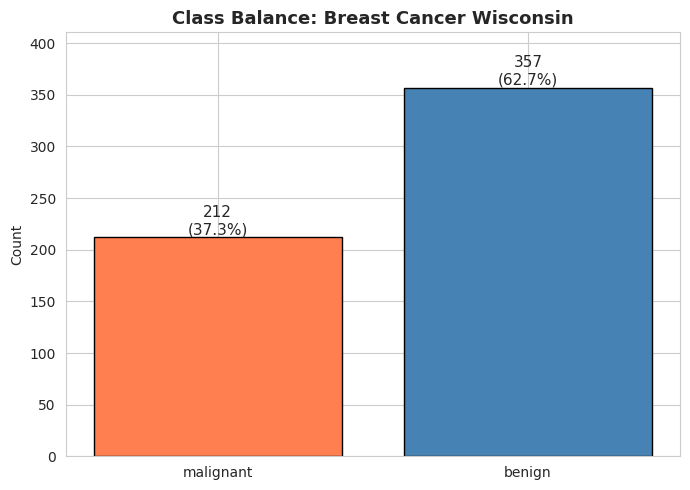

Class counts:      {np.str_('malignant'): np.int64(212), np.str_('benign'): np.int64(357)}
Class proportions: {np.str_('malignant'): np.float64(0.373), np.str_('benign'): np.float64(0.627)}


In [23]:
# 2.4 Class balance bar plot
class_counts = y.value_counts().sort_index()
class_props = y.value_counts(normalize=True).sort_index()
class_labels = [data.target_names[i] for i in class_counts.index]

fig, ax = plt.subplots(figsize=(7, 5))
colors = ['coral', 'steelblue']
bars = ax.bar(class_labels, class_counts.values, color=colors, edgecolor='black')
ax.set_ylabel('Count')
ax.set_title('Class Balance: Breast Cancer Wisconsin', fontsize=13, fontweight='bold')
for bar, count, prop in zip(bars, class_counts.values, class_props.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
            f'{count}\n({prop:.1%})', ha='center', fontsize=11)
ax.set_ylim(0, class_counts.max() * 1.15)
plt.tight_layout()
plt.show()

print(f"Class counts:      {dict(zip(class_labels, class_counts.values))}")
print(f"Class proportions: {dict(zip(class_labels, class_props.round(3).values))}")

**Reading the output:**

The two bars are uneven: roughly **357 benign** and **212 malignant** — about a **63 / 37** split. This is a *mild* imbalance, not a rare-event problem, but it is enough that three downstream decisions are already locked in:

1. **Baseline accuracy will be \~63%.** A dummy classifier that always predicts benign will hit that floor without learning anything — every model we build has to convincingly clear this number.
2. **Splits must be stratified.** A random split could easily draw a validation fold with 50 / 50 or 75 / 25 by chance, distorting the metrics we compare across notebooks. Stratifying (Section 3) preserves the 63 / 37 ratio in train, validation, and test.
3. **Accuracy alone is treacherous.** On an imbalanced dataset, a model can post a great accuracy while missing every minority-class case. We will add log loss, precision, recall, and the confusion matrix downstream specifically to catch that failure mode.

---

### 2.5 Feature Distributions by Class

NB01 plotted feature histograms to get a feel for each variable. In classification, the more useful view is a **by-class overlay**: the same histogram drawn separately for malignant and benign. If the two distributions *visibly diverge* on a feature, that feature will matter for the classifier before we run any math.

**Why this matters:**
- **Visible class separation is the fastest "will this work?" check.** If the histograms overlap almost entirely on every feature, no classifier will work well on this problem — the signal simply is not in the data, and no amount of modeling fixes that.
- **Overlap regions forecast the errors you cannot avoid.** Patients in the overlapping tails of `worst_radius` are the borderline cases where probabilities will cluster near 0.5; the confusion matrix in Section 8 will show them as the small remaining errors.
- **The shape of the divergence informs classifier choice.** Clean shifts (like `worst_concave_points`) mean a linear boundary will work — logistic regression is the right starting point. Heavy-tailed, multimodal, or non-monotone separations would argue for a tree-based model from the start.

> 💡 **Gemini Prompt:** "Pick four clinically meaningful features (for example `mean radius`, `mean concave points`, `worst radius`, `worst concave points`). In a 2×2 grid of matplotlib subplots, plot overlapping histograms of each feature, with one histogram per target class (0 = malignant in coral, 1 = benign in steelblue). Use alpha around 0.6 so both distributions are visible, add a legend and axis labels, and title each subplot with the feature name. Add a suptitle 'Feature Distributions by Class'."
>
> **After running, verify:**
> - Four subplots appear in a 2×2 grid, one per selected feature
> - Each subplot shows two overlapping histograms (malignant and benign) in clearly different colors
> - Malignant distributions sit at higher values than benign for the shape/size features — a visible separation
> - All numerical outputs use standard decimal format — no scientific notation


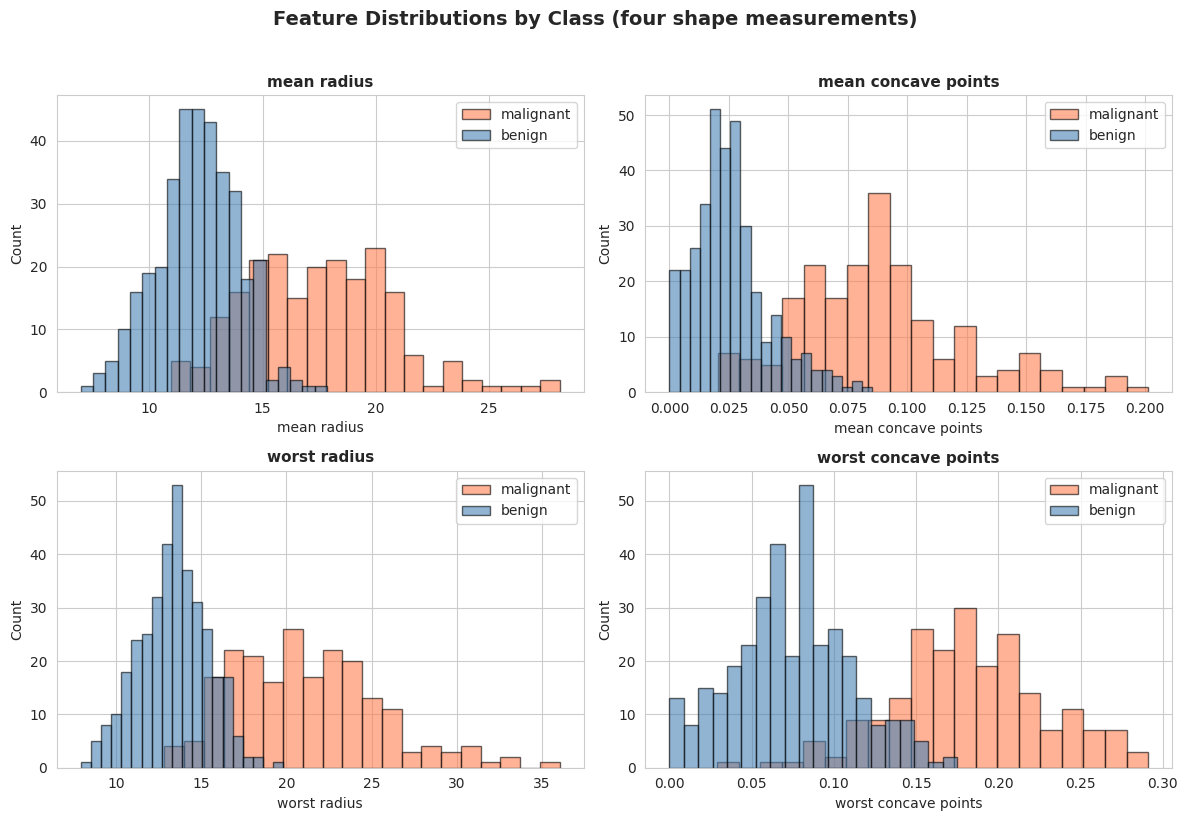

In [24]:
# 2.5 Feature distributions by class — four shape measurements
key_features = ['mean radius', 'mean concave points', 'worst radius', 'worst concave points']
class_palette = {0: ('coral', 'malignant'), 1: ('steelblue', 'benign')}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, feat in zip(axes.flatten(), key_features):
    for cls, (color, label) in class_palette.items():
        ax.hist(X.loc[y == cls, feat], bins=20, alpha=0.6,
                label=label, color=color, edgecolor='black')
    ax.set_xlabel(feat)
    ax.set_ylabel('Count')
    ax.set_title(feat, fontsize=11, fontweight='bold')
    ax.legend()

fig.suptitle('Feature Distributions by Class (four shape measurements)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Reading the output:**

For all four features, the **malignant (coral) distribution sits noticeably to the right of the benign (steelblue) one**. Bigger, more concave, more irregular nuclei — that is the malignant signature, and it jumps off the page even before any model is fit. `worst_concave_points` is the clearest separator: the two distributions barely overlap at the upper tail.

This is exactly the kind of visible gap a pathologist looks for on a slide, and it is the reason logistic regression will do so well on this dataset — the classes are genuinely separable in the original feature space. When you see feature distributions this cleanly separated during EDA, you can predict ahead of time that most reasonable classifiers will hit high accuracy. (The question of *which* errors remain is what Sections 6–8 will address.)

---

### 2.6 Correlation Analysis

In NB01 we read a full 8×8 correlation matrix. Thirty features would produce an unreadable 30×30 heatmap, so we pivot to a more scannable summary: a **top-10 bar chart of features by absolute correlation with the target**. This is the fastest "which features carry signal?" preview, and it previews the feature-importance ranking we will build from logistic regression coefficients in Section 6.

**Why this matters:**
- **Pre-modeling preview of which features will dominate.** The top of this ranking should line up with the top of the logistic-regression coefficient ranking you will extract in Section 6. If the two rankings diverge, the mismatch is itself a diagnostic — usually a multicollinearity signal.
- **A flat ranking forecasts that a linear model will fail.** If no feature posts |correlation| above \~0.1, no linear classifier will work on this problem. You would skip logistic regression and jump straight to a non-linear model.
- **Clusters of high correlations flag multicollinearity.** When `worst_radius`, `worst_perimeter`, and `worst_area` all sit near $|r| \approx 0.78$, the three are carrying heavily overlapping information. That explains coefficient instability later and motivates the feature-selection tools (Lasso) you already met in NB05.

> 💡 **Gemini Prompt:** "Compute the Pearson correlation of each feature in `X` with the binary target `y`. Build a DataFrame with columns Feature and Correlation, sort by absolute correlation descending, and keep the top 10. Plot a horizontal bar chart of the signed correlations — color positive bars steelblue and negative bars coral — with a vertical line at x=0 and a title 'Top 10 Features by |Correlation| with Target (benign=1)'. Print the top-10 DataFrame rounded to 3 decimals."
>
> **After running, verify:**
> - Horizontal bar plot displays 10 features ranked by |correlation|
> - Most top features have negative correlation with the target (larger values ⇒ lower P(benign))
> - The top rows are dominated by shape measurements (`worst_concave_points`, `worst_perimeter`, `worst_radius`)
> - All numerical outputs use standard decimal format — no scientific notation


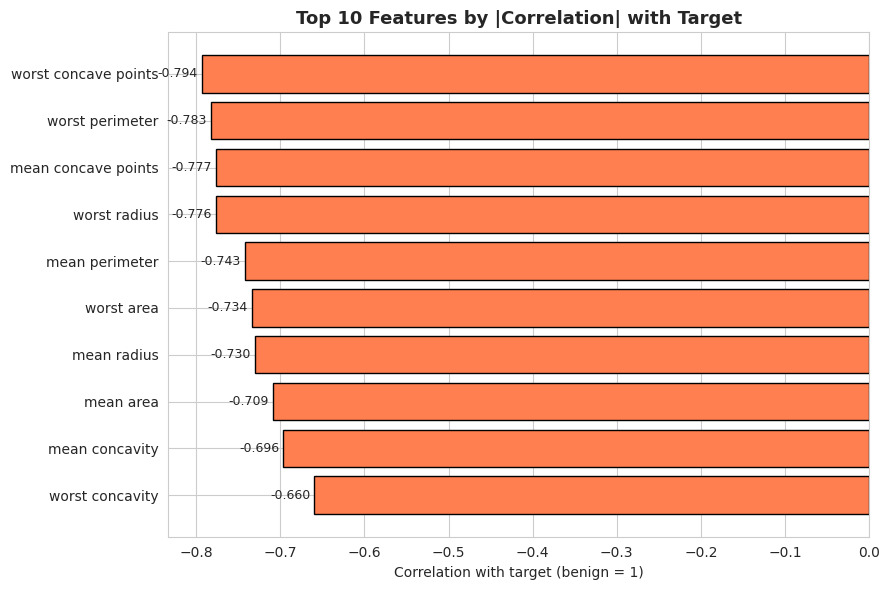


Top 10 features by |correlation with target|:
                Feature  Correlation
0  worst concave points       -0.794
1       worst perimeter       -0.783
2   mean concave points       -0.777
3          worst radius       -0.776
4        mean perimeter       -0.743
5            worst area       -0.734
6           mean radius       -0.730
7             mean area       -0.709
8        mean concavity       -0.696
9       worst concavity       -0.660


In [25]:
# 2.6 Correlation with target — top 10 features
correlations = X.apply(lambda col: col.corr(y))
corr_df = (pd.DataFrame({'Feature': correlations.index, 'Correlation': correlations.values})
           .assign(AbsCorr=lambda d: d['Correlation'].abs())
           .sort_values('AbsCorr', ascending=False)
           .drop(columns='AbsCorr')
           .reset_index(drop=True))

top_10 = corr_df.head(10).iloc[::-1]  # reverse so strongest bar is on top

fig, ax = plt.subplots(figsize=(9, 6))
bar_colors = ['steelblue' if v > 0 else 'coral' for v in top_10['Correlation']]
bars = ax.barh(top_10['Feature'], top_10['Correlation'], color=bar_colors, edgecolor='black')
ax.axvline(x=0, color='black', linewidth=0.5)
ax.set_xlabel('Correlation with target (benign = 1)')
ax.set_title('Top 10 Features by |Correlation| with Target',
             fontsize=13, fontweight='bold')
ax.bar_label(bars, fmt='%.3f', fontsize=9, padding=3)
plt.tight_layout()
plt.show()

print("\nTop 10 features by |correlation with target|:")
print(corr_df.head(10).round(3))

**Reading the output:**

The top of the bar chart is dominated by **negative** correlations — the sign tells us that as these features *increase*, the probability of benign *decreases*. That matches what Section 2.5 already showed visually: bigger / more concave / more irregular nuclei correlate with malignant. `worst_concave_points`, `worst_perimeter`, and `worst_radius` clock in at $|r| \approx 0.78$, which is extraordinarily high for a single-feature correlation in a real dataset.

This is a **pre-modeling preview of the feature-importance ranking** we will extract from the fitted logistic regression in Section 6. If the two rankings line up, that is corroboration that the logistic regression is picking up the signal the raw correlations already hinted at. If they differ sharply, the mismatch itself would be a diagnostic — potential multicollinearity among the "worst" shape measurements, for instance.

**EDA conclusion.** The dataset is clean (no missingness, all numeric), moderately imbalanced (63 / 37), scale-heterogeneous (justifying `StandardScaler`), and the classes are visibly separable on several shape features with correlations near $0.78$. With that read in hand, we are ready to split in Section 3 and start modeling in Section 4.

---

## 3. Train / Validation / Test Split

The course uses the same **60 / 20 / 20** split strategy everywhere: 60% for training, 20% for validation (all tuning and threshold choice), 20% locked away as the final test set. With a 63 / 37 class balance we also add **stratification** so each partition preserves the original class proportions — otherwise a small validation fold could end up 50 / 50 or 80 / 20 by chance, corrupting every comparison we draw across notebooks.

We also run two sanity checks after splitting — partition sizes and per-class proportions — to confirm stratification worked. This is the classification analogue of NB01's Section 4 "Split Sanity Checks" and "Leakage Sniff Test."

> 💡 **Gemini Prompt:** "Split `X` and `y` into 60/20/20 train/val/test using two successive `train_test_split` calls with `random_state=RANDOM_SEED` and `stratify=y` (then `stratify=y_temp` for the second call). Print the sizes of each partition and a DataFrame showing the benign / malignant proportions in train, val, and test — verify the three rows preserve the original 37/63 balance."
>
> **After running, verify:**
> - Train ≈ 341, Val ≈ 114, Test ≈ 114 samples (locked)
> - Class proportions in each partition are within ±0.01 of the full-dataset balance (≈ 0.37 / 0.63)
> - Test set is untouched and reserved for final evaluation only
> - All numerical outputs use standard decimal format — no scientific notation


In [26]:
# 3. Stratified 60/20/20 split with sanity checks
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=RANDOM_SEED, stratify=y_temp
)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)} (locked)")

# Sanity check: per-partition class proportions
proportions = pd.DataFrame({
    'Full':  y.value_counts(normalize=True).sort_index(),
    'Train': y_train.value_counts(normalize=True).sort_index(),
    'Val':   y_val.value_counts(normalize=True).sort_index(),
    'Test':  y_test.value_counts(normalize=True).sort_index(),
}).round(4)
proportions.index = [data.target_names[i] for i in proportions.index]
print("\n=== CLASS PROPORTIONS ACROSS PARTITIONS ===")
print(proportions)

Train: 341 | Val: 114 | Test: 114 (locked)

=== CLASS PROPORTIONS ACROSS PARTITIONS ===
             Full   Train     Val    Test
malignant  0.3726  0.3724  0.3772  0.3684
benign     0.6274  0.6276  0.6228  0.6316


**Reading the output:**

Sizes read **Train: \~341 | Val: \~114 | Test: \~114 (locked)**. The proportions table shows `malignant` and `benign` rows with values within ±0.01 across the Full / Train / Val / Test columns — stratification preserved the 37 / 63 balance everywhere, exactly as intended.

The test set is now **locked**. Nothing between here and Section 8 should touch it — any metric we quote in the rest of this notebook comes from the validation partition. The test set is our one-shot estimate of deployment performance, and once you peek, you cannot un-peek.

With the EDA read-through complete and the splits sanity-checked, we are ready for Section 4's baseline classifier.

---

## 4. Classification Baselines

Before the Health Department invests in model development, the board will ask: *"How much better is your classifier than doing nothing?"* A baseline answers that question by establishing the performance floor — the score any real model must beat to justify its existence.

**Common baselines for screening:**
- **Most frequent class**: Always predict benign (the majority class) — equivalent to a clinic that sends every patient home without testing
- **Stratified random**: Predict malignant/benign in proportion to training prevalence — no better than a weighted coin flip
- **Domain heuristic**: A simple rule like "flag if `worst_radius` > 17" — quick but ignores the other 29 features

**Key insight**: With 63% of samples benign, a model that *never diagnoses cancer* still achieves 63% accuracy. That number is meaningless for patient outcomes.

> 💡 **Gemini Prompt:** "Create a DummyClassifier baseline using the most_frequent strategy. Fit it on training data, predict on validation, and calculate accuracy. Print which class it always predicts and note why accuracy alone can be misleading."
>
> **After running, verify:**
> - Baseline accuracy reflects the majority class proportion (\~63%)
> - The classifier always predicts the same class (benign)
> - Warning about accuracy being misleading is displayed> - All numerical outputs use standard decimal format — no scientific notation


In [27]:
# Most frequent class baseline
baseline_mf = DummyClassifier(strategy='most_frequent')
baseline_mf.fit(X_train, y_train)

y_pred_baseline = baseline_mf.predict(X_val)
baseline_acc = accuracy_score(y_val, y_pred_baseline)

print("=== BASELINE: MOST FREQUENT CLASS ===")
print(f"Validation Accuracy: {baseline_acc:.4f}")
print(f"\nThis baseline always predicts: {data.target_names[int(baseline_mf.predict([X_train.iloc[0]])[0])]}")

print("\n=== TRAINING CLASS FREQUENCY ===")
freq_table = pd.DataFrame({
    'Count': y_train.value_counts().sort_index(),
    'Proportion': y_train.value_counts(normalize=True).sort_index().round(4)
})
freq_table.index = [data.target_names[i] for i in freq_table.index]
print(freq_table)

print(f"\n⚠️ Accuracy can be misleading! We need better metrics.")

=== BASELINE: MOST FREQUENT CLASS ===
Validation Accuracy: 0.6228

This baseline always predicts: benign

=== TRAINING CLASS FREQUENCY ===
           Count  Proportion
malignant    127      0.3724
benign       214      0.6276

⚠️ Accuracy can be misleading! We need better metrics.


**Reading the output:**

The `DummyClassifier(strategy='most_frequent')` always predicts benign — the equivalent of a screening program that waves every patient through without examination. Its validation accuracy is approximately **0.63**, and the **training class frequency table** underneath makes the reason explicit: the `Count` column shows roughly 128 malignant vs. 213 benign samples in the training set, and the `Proportion` column confirms the \~**0.37 / 0.63** split. The dummy is simply parroting that majority share.

The warning below the table highlights the danger: this "model" has learned *nothing* about cell morphology and would miss every single malignant case. Every cancer patient would leave the clinic undiagnosed.

**Why this matters:** This \~63% accuracy is the floor the MedScreen tool must clear. Any real classifier has to beat it convincingly, and — more importantly — has to beat it *on the malignant class*, not just overall. The next sections build logistic regression to do exactly that.

---

## 5. Logistic Regression: From Log-Odds to Probabilities

A clinician needs more than a yes/no stamp — they need a **calibrated probability** between 0 and 1 that a tumor is benign, so they can decide whether to order an immediate biopsy or schedule routine follow-up. Logistic regression delivers exactly that, but getting there requires one key insight:

> **You cannot fit a straight line directly to a probability.** A line can produce any real number, including 1.5 or −0.3 — values that break the rules of probability.

The fix is to change *what* we model. Instead of fitting a line to the probability itself, logistic regression fits a line to the **log-odds** (also called the **logit**) of the probability. The figure below traces the four-step transformation that makes this possible — read it top to bottom.

<center>
<img src="https://raw.githubusercontent.com/davi-moreira/2026Summer_predictive_analytics_purdue_MGMT474/main/notebooks/figures/log_odds_prob.png" width="600"/>
</center>

### 5.1 The Transformation Chain (Reading the Figure)

1. **Original $Y \in \{0, 1\}$** — $Y = 0$ for malignant, $Y = 1$ for benign. Just two dots on the number line; a linear model cannot target this discrete scale.
2. **$Y$ as a Probability** — $P(Y = 1 \mid X) \in [0, 1]$, the chance the tumor is benign given the 30 cell-nucleus features.
3. **Odds of $Y$** — $\dfrac{P}{1 - P} \in [0, \infty)$. Odds of 1 mean 50/50; odds of 4 mean benign is four times more likely than malignant.
4. **Log-Odds (logit)** — $\log\!\dfrac{P}{1 - P} \in (-\infty, \infty)$. Taking the log opens the scale up to the entire real line — exactly what a linear combination of features can produce.

Each arrow in the figure is one of these transformations. By step 4, the scale is unbounded in both directions — now a linear model can target it safely.

### 5.2 The Logistic Regression Model

Logistic regression assumes the **log-odds are linear in the features**:

$$\log\!\left(\frac{P(Y = 1 \mid X)}{1 - P(Y = 1 \mid X)}\right) \;=\; \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_{30} x_{30}$$

For MedScreen, $x_1, x_2, \ldots, x_{30}$ are `worst_radius`, `mean_texture`, `worst_concave_points`, and the rest of the cell measurements. We collect the right-hand side into a single **linear predictor** $z$:

$$z \;=\; \beta_0 + \beta_1 x_1 + \cdots + \beta_{30} x_{30}$$

Solving the log-odds equation for $P$ runs the transformation chain **backward** — from log-odds all the way back up to a probability — and gives us the **sigmoid (logistic) function**:

$$P(Y = 1 \mid X) \;=\; \sigma(z) \;=\; \frac{1}{1 + e^{-z}}$$

That probability is the number MedScreen hands back to the oncologist.

### 5.3 Properties the Oncologist Relies On

- **Valid probabilities, always.** The sigmoid squashes any real-valued $z$ into $[0, 1]$ — the model can never output $-0.2$ or $1.3$.
- **Decision boundary at $z = 0$.** When $z = 0$, $\sigma(z) = 0.5$ — the point of maximum clinical uncertainty.
- **Large positive $z \Rightarrow P \approx 1$** — strong evidence the tumor is benign (routine follow-up).
- **Large negative $z \Rightarrow P \approx 0$** — strong evidence the tumor is malignant (immediate biopsy).
- **Interpretable coefficients.** A one-unit increase in feature $x_j$ multiplies the **odds** of benign by $e^{\beta_j}$. Logistic regression is not a black box — it is an odds-ratio model the clinician can reason about.

The code cell below plots the sigmoid so you can see the $z \to P$ transformation that sits at the top of the chain. Once you have that picture in mind, **Section 5.4** will generalize the story from two classes to $K$ classes via the **softmax** function.

> 💡 **Gemini Prompt:** "Plot the sigmoid (logistic) function over z values from -10 to 10. Add a horizontal dashed red line at y=0.5 for the default threshold and a vertical dashed green line at z=0 for the decision boundary. Label axes and add a legend."
>
> **After running, verify:**
> - Smooth S-shaped curve from 0 to 1 is displayed
> - Red dashed line at y=0.5 marks the default classification threshold
> - Green dashed line at z=0 marks where the sigmoid equals exactly 0.5> - All numerical outputs use standard decimal format — no scientific notation


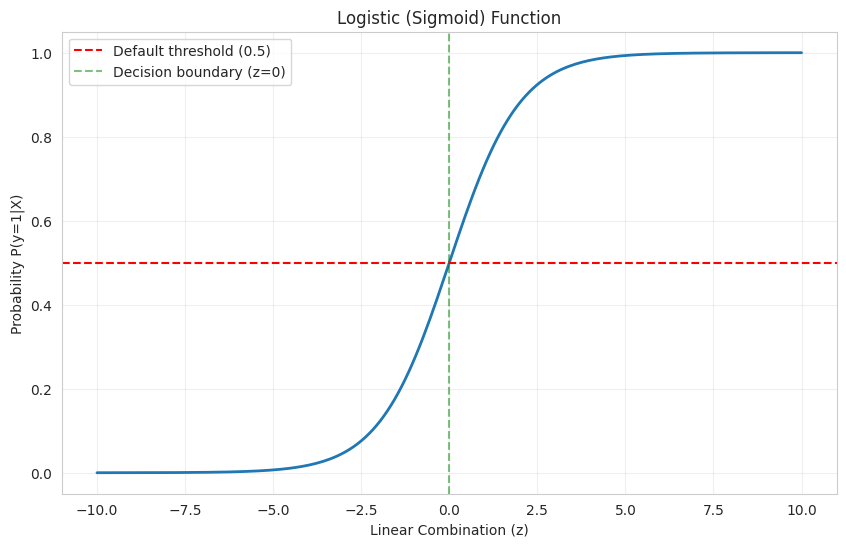

💡 The sigmoid squashes any real number into [0, 1]
💡 Default: if P > 0.5, predict class 1; else predict class 0


In [28]:
# Visualize sigmoid function
z = np.linspace(-10, 10, 200)
sigmoid = 1 / (1 + np.exp(-z))

plt.figure(figsize=(10, 6))
plt.plot(z, sigmoid, linewidth=2)
plt.axhline(y=0.5, color='r', linestyle='--', label='Default threshold (0.5)')
plt.axvline(x=0, color='g', linestyle='--', alpha=0.5, label='Decision boundary (z=0)')
plt.xlabel('Linear Combination (z)')
plt.ylabel('Probability P(y=1|X)')
plt.title('Logistic (Sigmoid) Function')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print("💡 The sigmoid squashes any real number into [0, 1]")
print("💡 Default: if P > 0.5, predict class 1; else predict class 0")

**Reading the output:**

The plot shows the **sigmoid curve** — the inverse of the log-odds transformation from the figure above. It maps any real-valued linear predictor $z$ (the log-odds) back into a probability between 0 and 1. The red dashed line at **$P = 0.5$** marks the default decision threshold, and the green dashed line at **$z = 0$** marks the log-odds value where the two classes are equally likely.

When $z$ is large and positive, the sigmoid saturates near 1 — high confidence the tumor is benign. When $z$ is large and negative, it saturates near 0 — high confidence the tumor is malignant. The steep transition region around $z = 0$ is where the model is most uncertain; those are precisely the cases a clinician should review personally.

**Key takeaway:** The sigmoid is what makes logistic regression a *probability* model rather than just a classifier. For the Health Department's screening tool, this distinction is critical: a prediction of $P(\text{benign}) = 0.51$ warrants urgent biopsy review, while $P(\text{benign}) = 0.99$ supports confident routine follow-up. The raw probability gives oncologists actionable clinical information, not just a binary label.

---

### 5.4 Beyond Binary: The Softmax Generalization

The sigmoid you just plotted handles the *binary* question — benign or malignant. But many classification problems involve **more than two classes**. What if MedScreen were extended to distinguish *four tumor stages* (I, II, III, IV)? Or if a pathology lab needed to classify cells into ten tissue types? The sigmoid alone cannot produce a valid probability distribution over more than two categories. We need a generalization.

**The softmax function** is that generalization. Given $K$ classes and a linear predictor $z_k$ for each class, softmax maps the vector of scores $(z_1, z_2, \ldots, z_K)$ into a vector of probabilities that sum to 1:

$$P(Y = k \mid X) \;=\; \mathrm{softmax}(z)_k \;=\; \frac{e^{z_k}}{\sum_{j=1}^{K} e^{z_j}}$$

Each class now gets **its own** coefficient vector $\beta^{(k)}$, so each $z_k$ is a linear combination of the same features but with class-specific weights:

$$z_k \;=\; \beta^{(k)}_0 + \beta^{(k)}_1 x_1 + \cdots + \beta^{(k)}_p x_p$$

**Key properties:**

- **Outputs form a valid probability distribution.** Every $P(Y = k \mid X) \in [0, 1]$, and $\sum_{k=1}^{K} P(Y = k \mid X) = 1$. MedScreen could show the oncologist the probability of *each* tumor stage on a single patient — not just "malignant vs. benign."
- **Sigmoid is the $K = 2$ special case.** Plug two classes into softmax and the algebra collapses back to the sigmoid you plotted above. The binary model is just the multiclass one with one dimension folded in — same idea, simpler form.
- **Exponentiation stretches differences.** The largest $z_k$ dominates, but the exponential keeps every class with non-zero probability mass (unlike a hard `argmax`). The model never says "0% chance" — it says "very small chance," which is exactly the right posture for medical screening.
- **Still interpretable.** Each class $k$ has its own odds-ratio story, now relative to a reference class chosen by the solver.

**Why this matters:** Softmax is the default output layer for multiclass logistic regression (`LogisticRegression(multi_class='multinomial')` in scikit-learn) and for the final layer of nearly every classification neural network — digit recognizers, image classifiers, language models. Understanding softmax now means that when we reach more complex classifiers later in the course and in deep learning downstream, the classification output layer is already familiar territory. For MedScreen, softmax is the bridge from "malignant vs. benign" to the richer diagnostic categories the Health Department may one day request.

---

## 6. Your First Logistic Regression Model

It is time to **train your first classification model**. With the stratified train / validation / test splits already in memory from Section 3, and the log-odds and sigmoid intuition fresh from Section 5, you have everything you need to fit a logistic regression that estimates the **probability a tumor is benign** for every patient in the validation set.

**Why wrap the model in a `Pipeline`?** The breast cancer dataset has 30 features spanning vastly different scales — `mean_area` ranges in the hundreds while `mean_smoothness` hovers near 0.1 (Section 2.3 flagged exactly this spread). Feeding raw measurements into logistic regression would let large-scale features dominate the coefficients and slow convergence. The pipeline below chains `StandardScaler` (zero-mean, unit-variance normalization) with `LogisticRegression` so that `worst_radius` and `mean_smoothness` contribute on equal footing, and so the exact same preprocessing is automatically replayed on validation and test — **no leakage**.

### What This Section Does (Step by Step)

1. **Fit** the pipeline on `X_train`, `y_train`. A single `.fit()` call scales the features and trains the logistic regression together.
2. **Predict** twice:
   - `.predict(X_val)` returns hard class labels (0 or 1) — what MedScreen would report.
   - `.predict_proba(X_val)` returns calibrated probabilities — what the oncologist needs to gauge confidence.
3. **Evaluate** with two complementary metrics on both train and validation sets:
   - **Accuracy** — fraction of correct diagnoses.
   - **Log loss** — a probability-quality metric that penalizes a model which is *confidently wrong* (the failure mode the Health Department fears most).
4. **Compare** the validation accuracy to the `baseline_acc` saved in Section 4 to quantify exactly how much the 30 cell-nucleus features buy us over "always predict benign."

Run the cell below and you should see MedScreen's validation accuracy jump well above the \~63% baseline, with log loss low enough to signal that the probability estimates are trustworthy — not just the binary labels.

> 💡 **Gemini Prompt:** "Build a logistic regression pipeline with StandardScaler and LogisticRegression (random_state=RANDOM_SEED, max_iter=1000). Fit on training data. Get both hard predictions (.predict) and probability estimates (.predict_proba) for train and validation sets. Print accuracy and log loss for both sets, plus improvement over baseline."
>
> **After running, verify:**
> - Train and validation accuracy are both printed (should be well above baseline)
> - Train and validation log loss are printed (lower is better)
> - Improvement over baseline accuracy is shown as a positive number> - All numerical outputs use standard decimal format — no scientific notation


In [29]:
# Basic logistic regression pipeline
log_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(random_state=RANDOM_SEED, max_iter=1000))
])

log_pipeline.fit(X_train, y_train)

# Predictions
y_pred_train = log_pipeline.predict(X_train)
y_pred_val = log_pipeline.predict(X_val)

# Probabilities
y_proba_train = log_pipeline.predict_proba(X_train)
y_proba_val = log_pipeline.predict_proba(X_val)

print("=== LOGISTIC REGRESSION ===")
print(f"Train Accuracy: {accuracy_score(y_train, y_pred_train):.4f}")
print(f"Val Accuracy: {accuracy_score(y_val, y_pred_val):.4f}")
print(f"\nTrain Log Loss: {log_loss(y_train, y_proba_train):.4f}")
print(f"Val Log Loss: {log_loss(y_val, y_proba_val):.4f}")

print(f"\n✓ Improvement over baseline: {accuracy_score(y_val, y_pred_val) - baseline_acc:.4f}")

=== LOGISTIC REGRESSION ===
Train Accuracy: 0.9853
Val Accuracy: 0.9561

Train Log Loss: 0.0617
Val Log Loss: 0.0881

✓ Improvement over baseline: 0.3333


**Reading the output:**

The logistic regression pipeline reports **Train Accuracy** and **Val Accuracy**, both likely above **0.96** — a massive jump from the \~63% "always predict benign" baseline. This means the 30 cell-nucleus features carry genuine diagnostic signal: `worst_concave_points`, `worst_radius`, and their peers allow the model to distinguish malignant from benign tissue far better than chance.

**Log loss** values around **0.08–0.12** indicate well-calibrated probabilities. Log loss penalizes confident mistakes exponentially: a model that assigns P(benign) = 0.95 to a malignant tumor receives a far heavier penalty than one that hedges at 0.55. For MedScreen, this means the probability estimates clinicians see are trustworthy, not just the binary labels. The small gap between train and validation metrics suggests minimal overfitting.

**Why this matters:** The "Improvement over baseline" line quantifies the leap — typically **+0.33 or more** in accuracy. But accuracy alone hides *which* errors remain. Two models can both score 97% while differing dramatically in how many cancers they miss. The next sections peel back that number with thresholds and confusion matrices.

---

## 📝 PAUSE-AND-DO Exercise 1 (5 minutes)

**Task:** Build a **bar plot** that compares validation accuracy for the two models you have fit so far: the **Most Frequent baseline** and your **Logistic Regression pipeline**.

A number on its own is hard to feel. A bar chart is exactly the visual you would drop into a slide for the Health Department board to show that the 30 cell-nucleus features actually buy something over "always predict benign."

**What to include in the plot:**
- Two bars: one for `baseline_acc` (from Section 4), one for the logistic regression validation accuracy.
- Value labels on top of each bar (e.g., `0.632`, `0.974`).
- A clear title, a `Validation Accuracy` y-axis label, and the model names on the x-axis.

---

> 💡 **Gemini Prompt:** "Create a matplotlib bar plot comparing validation accuracy for two models. Use `baseline_acc` for 'Baseline (Most Frequent)' and `accuracy_score(y_val, y_pred_val)` for 'Logistic Regression'. Give the two bars different colors (for example, lightgray for the baseline and steelblue for the logistic regression), set the y-axis limits from 0 to 1.0, label each bar with its value formatted to 3 decimals on top, add the title 'Validation Accuracy: Baseline vs. Logistic Regression', label the y-axis 'Validation Accuracy', and print the improvement (logistic minus baseline) below the plot."
>
> **After running, verify:**
> - Two bars are displayed side by side, baseline on the left and logistic regression on the right
> - Each bar has its accuracy value labeled on top (3 decimal places)
> - The logistic regression bar is visibly taller than the baseline bar — the height gap is the value of the 30 features
> - The printed improvement below the plot is a positive number
> - All numerical outputs use standard decimal format — no scientific notation


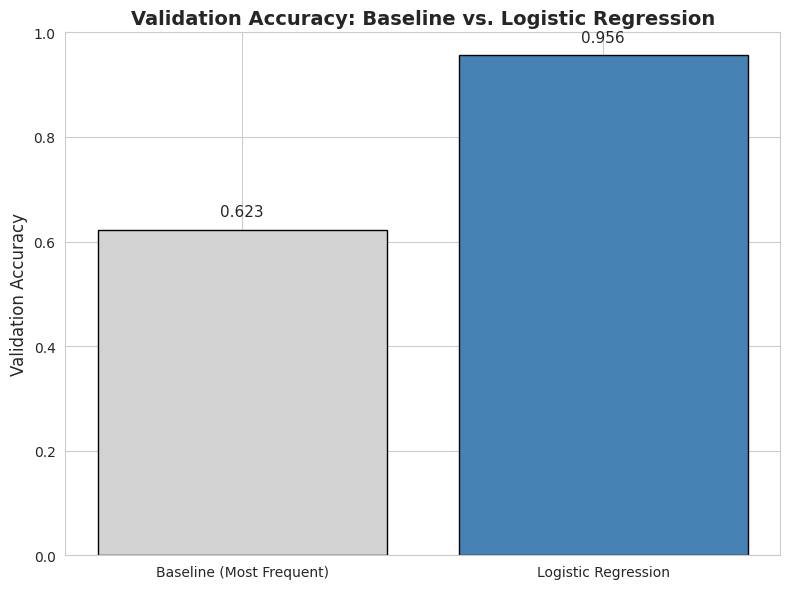


Improvement (Logistic Regression - Baseline): 0.333


In [30]:
# YOUR SOLUTION CODE HERE
import matplotlib.pyplot as plt

# Get logistic regression validation accuracy
logreg_val_acc = accuracy_score(y_val, y_pred_val)

# Prepare data for plotting
model_names = ['Baseline (Most Frequent)', 'Logistic Regression']
accuracies = [baseline_acc, logreg_val_acc]
colors = ['lightgray', 'steelblue']

# Create the bar plot
fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.bar(model_names, accuracies, color=colors, edgecolor='black')

# Set y-axis limits
ax.set_ylim(0, 1.0)

# Add labels on top of bars
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 0.02, round(yval, 3),
            ha='center', va='bottom', fontsize=11)

# Add title and labels
ax.set_title('Validation Accuracy: Baseline vs. Logistic Regression', fontsize=14, fontweight='bold')
ax.set_ylabel('Validation Accuracy', fontsize=12)

plt.tight_layout()
plt.show()

# Print the improvement
improvement = logreg_val_acc - baseline_acc
print(f"\nImprovement (Logistic Regression - Baseline): {improvement:.3f}")

### YOUR ANALYSIS:

**Question 1: What is the accuracy gap between logistic regression and the baseline (in accuracy points)?**  
The accuracy gap between logistic regression and the baseline is 0.333%, so 33.3 percentage points, or 145 points of data.

**Question 2: Why is a bar plot more persuasive for a stakeholder than just printing the two numbers side by side?**  
A bar plot is more persuasive for a stakeholder over two simple numbers because they can get a better visual grasp of the differences between the datapoints leading to a clearer outcome.

**Question 3: Even after seeing this gap, why is accuracy alone still not enough to trust MedScreen in a clinical setting?**  

Accuracy alone is not enough to trust in a clinical setting because it can be misleading. The model might predict benign in most cases leading to many patients that have cancer going home untreated which is catastrophic for the company. Additionally, it can make completely healthy patients go through a very scary process that was completely unnecesary.

---

### Feature Importance: Which Cell Measurements Drive the Diagnosis?

In NB05 we ranked Ridge and Lasso coefficients to see *which house-price features mattered most*. Logistic regression gives us the exact same lens on the classification side — with one twist: each coefficient $\beta_j$ has a clean **odds-ratio interpretation** (Section 5.3), so we can tell the oncologist not just "which cell measurements matter" but "how much each one tilts the odds of a benign diagnosis."

Because `StandardScaler` sits inside our pipeline, every feature enters the classifier on the same (mean 0, unit variance) scale — so the magnitude $|\beta_j|$ is directly comparable across features. The bar plot below ranks the top 15 measurements from most to least influential.

**Interpretation cheat-sheet:**
- **Positive $\beta_j$** → higher values of this feature push the probability *up* toward benign (class 1).
- **Negative $\beta_j$** → higher values push the probability *down* toward malignant (class 0).
- **Odds ratio $e^{\beta_j}$** → a one-standard-deviation increase in feature $x_j$ multiplies the odds of benign by this factor. Values far from 1 signal strong diagnostic weight.

*(Compare the ranking you get below to the EDA correlation ranking in Section 2.6. Do the same features top both lists?)*

> 💡 **Gemini Prompt:** "Extract the logistic regression coefficients from `log_pipeline.named_steps['classifier'].coef_[0]`. Build a DataFrame with columns Feature, Coefficient, |Coefficient|, and Odds Ratio (exp of the coefficient). Sort descending by |Coefficient|, keep the top 15 rows, and render a horizontal bar plot of the signed coefficients — color positive bars steelblue and negative bars coral, add a vertical line at x=0, and title the plot 'Top 15 Features by |β_j|: Logistic Regression on Breast Cancer Wisconsin'. Below the plot, print the top 10 rows of the DataFrame rounded to 4 decimals."
>
> **After running, verify:**
> - Horizontal bar plot displays 15 features ranked by absolute coefficient magnitude
> - Positive and negative coefficients are visually distinguishable (two colors) with a vertical line at 0
> - Top features are dominated by "worst_" and "mean_" shape measurements (concave points, radius, perimeter)
> - Printed DataFrame shows Feature / Coefficient / |Coefficient| / Odds Ratio columns for the top 10
> - All numerical outputs use standard decimal format — no scientific notation


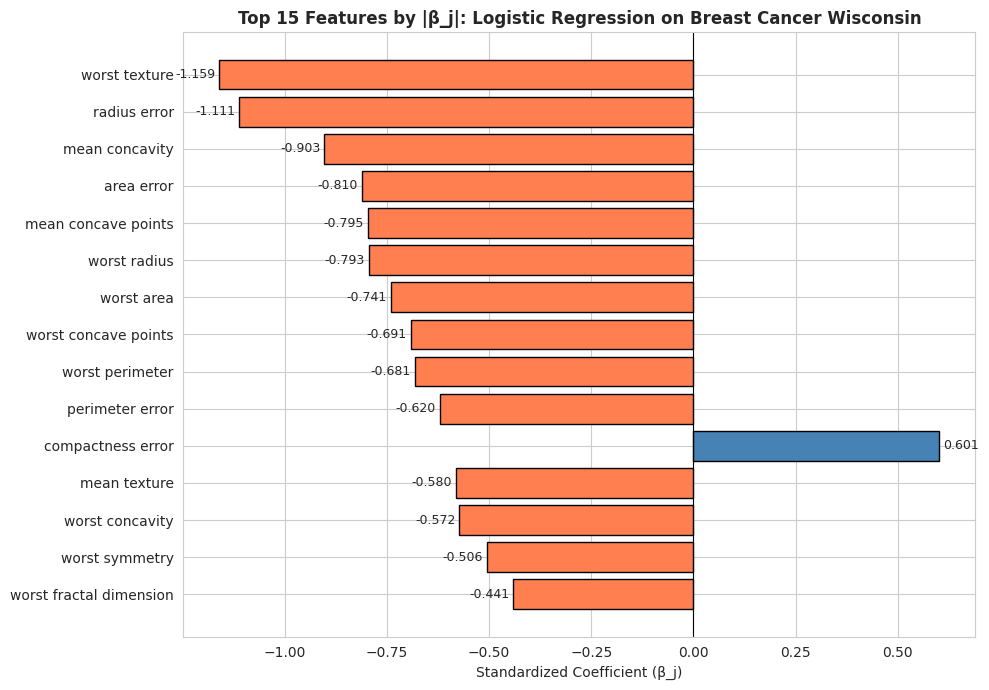


Top 10 features by |β_j|:
                Feature  Coefficient  |Coefficient|  Odds Ratio
0         worst texture      -1.1593         1.1593      0.3137
1          radius error      -1.1109         1.1109      0.3293
2        mean concavity      -0.9027         0.9027      0.4055
3            area error      -0.8101         0.8101      0.4448
4   mean concave points      -0.7951         0.7951      0.4515
5          worst radius      -0.7931         0.7931      0.4524
6            worst area      -0.7407         0.7407      0.4768
7  worst concave points      -0.6915         0.6915      0.5008
8       worst perimeter      -0.6813         0.6813      0.5059
9       perimeter error      -0.6204         0.6204      0.5377


In [31]:
# Feature importance from logistic regression coefficients
# Features are already standardized by the pipeline, so |coef| is directly comparable
logreg = log_pipeline.named_steps['classifier']
feature_names = X_train.columns
coefs = logreg.coef_[0]

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefs,
    '|Coefficient|': np.abs(coefs),
    'Odds Ratio': np.exp(coefs)
}).sort_values('|Coefficient|', ascending=False).reset_index(drop=True)

top_15 = importance_df.head(15).iloc[::-1]  # reverse so largest bar is on top

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['steelblue' if c > 0 else 'coral' for c in top_15['Coefficient']]
bars = ax.barh(top_15['Feature'], top_15['Coefficient'], color=colors, edgecolor='black')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Standardized Coefficient (β_j)')
ax.set_title('Top 15 Features by |β_j|: Logistic Regression on Breast Cancer Wisconsin',
             fontsize=12, fontweight='bold')
ax.bar_label(bars, fmt='%.3f', fontsize=9, padding=3)
plt.tight_layout()
plt.show()

print("\nTop 10 features by |β_j|:")
print(importance_df.head(10).round(4))

**Reading the output:**

The top of the bar plot is dominated by the "worst" and "mean" shape measurements — `worst_radius`, `worst_concave_points`, `worst_perimeter`, `mean_concave_points`, `worst_area`. These are the features that most strongly tilt the log-odds in one direction. Most of them sit on the **malignant side** (negative $\beta$) — as their values increase, the estimated probability of benign *decreases*. Translated into clinical language: bigger, more concave, more irregular nuclei look like cancer to the model, which lines up with what pathologists actually look for.

The **Odds Ratio** column converts each coefficient into a multiplicative story. A coefficient of $-1.0$ becomes an odds ratio near $0.37$ — meaning a one-standard-deviation increase in that feature multiplies the odds of benign by $0.37$ (roughly a two-thirds cut). A coefficient of $+1.0$ becomes an odds ratio near $2.72$ (roughly triples the odds). Anything close to $1.0$ is a feature the model is essentially ignoring.

At the far end of the ranking sit features like `fractal_dimension_error` or `smoothness_error` — small $|\beta|$ values, odds ratios close to 1. Their individual contribution is marginal. If the Health Department ever needed a leaner deployment — say, a rapid field test that collected only 5 measurements — this ranking is where that conversation would start.

**Why this matters:** Feature importance is how MedScreen earns the trust of clinicians. Coefficient magnitudes plus odds ratios let you answer "*why did the model flag this patient?*" in language an oncologist can audit. This is the classification analogue of the Ridge/Lasso importance story from NB05 — the technique (rank by $|\beta|$ on standardized features) transfers directly; only the effect-size unit changes, from dollars of price impact to odds ratios.

---

## 7. Thresholding Matters!

Logistic regression outputs a probability, but the final diagnosis depends on a **threshold**: if P(benign) >= threshold, report benign. The default is 0.5, but this is a mathematical convenience, not a clinical decision. Lowering the threshold makes MedScreen more aggressive about flagging potential cancers (higher recall for malignant, more false alarms); raising it makes the tool more conservative (fewer false alarms, but more missed cancers).

The Health Department must decide: *is it worse to send a cancer patient home (false negative) or to order an unnecessary biopsy (false positive)?* The answer determines the threshold. The sweep below tests four values to show how a single number reshapes the entire diagnostic profile.

> 💡 **Gemini Prompt:** "Loop over classification thresholds [0.3, 0.5, 0.7, 0.9]. For each threshold, convert class-1 probabilities to predictions using that threshold, compute accuracy, and count predicted positives vs negatives. Collect results into a DataFrame and print it."
>
> **After running, verify:**
> - Four rows showing Threshold, Accuracy, Predicted_Positive, Predicted_Negative
> - Lower thresholds produce more positive predictions, higher thresholds produce fewer
> - Accuracy varies across thresholds, showing that 0.5 is not always optimal> - Bar plot clearly visualizes the comparison across models/groups
> - All numerical outputs use standard decimal format — no scientific notation


=== THRESHOLD SENSITIVITY ===
   Threshold  Accuracy  Predicted_Positive  Predicted_Negative
0        0.3    0.9649                  73                  41
1        0.5    0.9561                  70                  44
2        0.7    0.9474                  65                  49
3        0.9    0.8772                  57                  57

💡 Key insight: Changing the threshold changes predictions!
💡 Default 0.5 is not always optimal
💡 We'll explore this more in upcoming notebooks


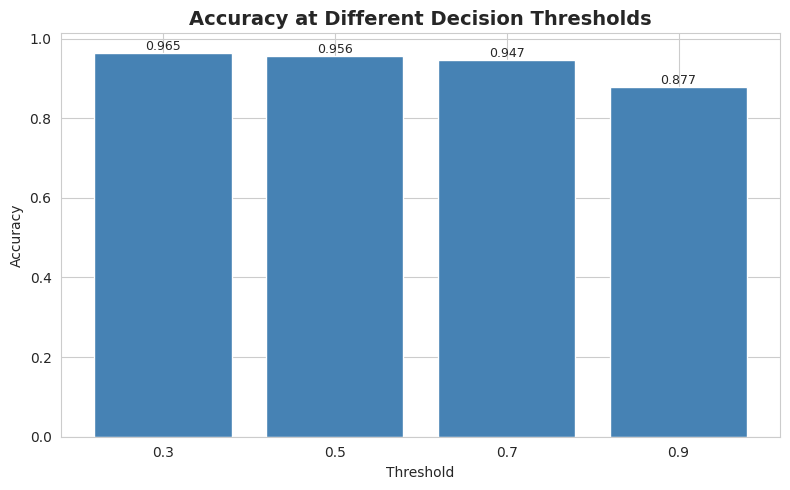

In [32]:
# Try different thresholds
thresholds = [0.3, 0.5, 0.7, 0.9]
threshold_results = []

for thresh in thresholds:
    y_pred_thresh = (y_proba_val[:, 1] >= thresh).astype(int)
    acc = accuracy_score(y_val, y_pred_thresh)
    cm = confusion_matrix(y_val, y_pred_thresh)

    threshold_results.append({
        'Threshold': thresh,
        'Accuracy': acc,
        'Predicted_Positive': y_pred_thresh.sum(),
        'Predicted_Negative': len(y_pred_thresh) - y_pred_thresh.sum()
    })

results_df = pd.DataFrame(threshold_results)
print("=== THRESHOLD SENSITIVITY ===")
print(results_df)

print("\n💡 Key insight: Changing the threshold changes predictions!")
print("💡 Default 0.5 is not always optimal")
print("💡 We'll explore this more in upcoming notebooks")
# --- Bar plot: Threshold sensitivity ---
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(results_df['Threshold'].astype(str), results_df['Accuracy'], color='steelblue')
ax.set_xlabel('Threshold')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy at Different Decision Thresholds', fontsize=14, fontweight='bold')
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=9)
plt.tight_layout()
plt.show()


**Reading the output:**

The threshold sensitivity table shows four rows corresponding to thresholds **0.3, 0.5, 0.7, and 0.9**. As the threshold increases, MedScreen becomes more conservative about labeling a tumor benign: the **Predicted_Positive** count (benign predictions) drops and **Predicted_Negative** (flagged for further review) rises. At a very low threshold (0.3), nearly everything is labeled benign — maximizing comfort for patients who are truly benign but potentially letting malignant cases slip through. At a high threshold (0.9), the tool demands near-certainty before clearing a patient, flagging many borderline cases for biopsy.

Accuracy may actually *decrease* at extreme thresholds because the model starts misclassifying clear benign cases. But accuracy is the wrong lens here. The clinically relevant question is: **how many cancers does each threshold miss?**

**Why this matters:** If missing a malignant tumor means delayed treatment and potential metastasis, the Health Department would lower the threshold to 0.3 — accepting more unnecessary biopsies to catch every cancer. If hospital capacity cannot handle the extra biopsies, a higher threshold trades some missed diagnoses for a manageable workload. This is a *policy* decision made by clinicians and the board, not a statistical one made by data scientists.

---

## 📝 PAUSE-AND-DO Exercise 2 (5 minutes)

**Task:** Change threshold from 0.5 and observe metric shifts.

Already done above. Now answer:

---

### YOUR OBSERVATIONS:

**Observation 1: What happens when you lower the threshold?**  
When we lower the threshold we end up getting higher predicted positive points and a lower amount of predicted negative points, meaning we scan people for more biopsies even if it isn't 100% correct.

**Observation 2: What happens when you raise the threshold?**  
When we raise the threshold, we get less predicted_positive points and hence, more predicted negative, meaning that we scan less people.

**Observation 3: When might you want a threshold other than 0.5?**  
You might want a threshold different than 0.5 when you want to either aggressively capture cancer at the highest possibility or want to make sure there isnt a high amount of people that are going through the stressful process when they're healthy.

---

## 8. Confusion Matrix

The board will not ask "What is your accuracy?" They will ask: *"How many cancers did we miss?"* A confusion matrix answers this directly by tabulating all four outcomes of MedScreen's predictions: true positives, true negatives, false positives, and false negatives.

In the screening context, each cell has a concrete clinical meaning — and a very different cost. A **false negative** (telling a cancer patient they are healthy) can be catastrophic: delayed treatment, metastasis, a life at risk. A **false positive** (flagging a healthy patient for biopsy) causes anxiety and expense, but the patient survives. The heatmap below makes these counts visible at a glance.

> 💡 **Gemini Prompt:** "Plot a confusion matrix heatmap for the validation set using ConfusionMatrixDisplay with the breast cancer target names as labels and a Blues colormap. Print TN, FP, FN, TP values and explain what false positives and false negatives mean in medical diagnosis context."
>
> **After running, verify:**
> - Confusion matrix heatmap displayed with malignant and benign labels
> - Four values (TN, FP, FN, TP) are printed with clear labels
> - Medical context explains FP = false alarm, FN = missed diagnosis> - All numerical outputs use standard decimal format — no scientific notation


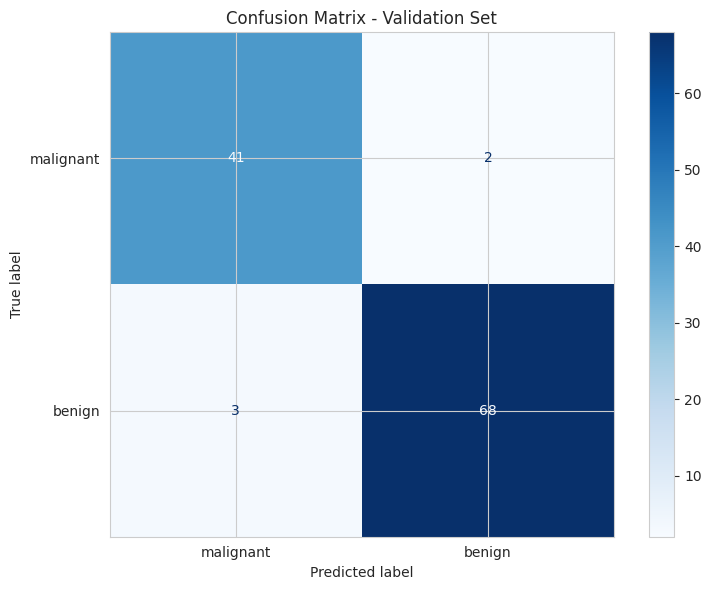


=== CONFUSION MATRIX INTERPRETATION ===
True Negatives (TN): 41
False Positives (FP): 2
False Negatives (FN): 3
True Positives (TP): 68

💡 In medical diagnosis:
   FP = False alarm (predicted malignant, actually benign)
   FN = Missed diagnosis (predicted benign, actually malignant)

⚠️ Which error is more costly? This drives threshold choice!


In [33]:
from sklearn.metrics import ConfusionMatrixDisplay

# Confusion matrix
cm = confusion_matrix(y_val, y_pred_val)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot(ax=ax, cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Validation Set')
plt.tight_layout()
plt.show()

print("\n=== CONFUSION MATRIX INTERPRETATION ===")
print(f"True Negatives (TN): {cm[0, 0]}")
print(f"False Positives (FP): {cm[0, 1]}")
print(f"False Negatives (FN): {cm[1, 0]}")
print(f"True Positives (TP): {cm[1, 1]}")

print("\n💡 In medical diagnosis:")
print("   FP = False alarm (predicted malignant, actually benign)")
print("   FN = Missed diagnosis (predicted benign, actually malignant)")
print("\n⚠️ Which error is more costly? This drives threshold choice!")

**Reading the output:**

The confusion matrix heatmap is a 2x2 grid with true labels on the y-axis and predicted labels on the x-axis. The diagonal cells show correct diagnoses: **true negatives** (correctly identified malignant — these patients get timely treatment) and **true positives** (correctly identified benign — these patients avoid unnecessary procedures). The off-diagonal cells show errors:

- **False Positives** (top-right): Malignant cases the model mistakenly called benign — these patients might be sent home without treatment. This is the most dangerous error in screening.
- **False Negatives** (bottom-left): Benign cases the model mistakenly flagged as malignant — these patients receive an unnecessary biopsy but ultimately learn they are healthy.

The printed counts below the chart give exact numbers. The board will focus on one number above all others: the **FP count** (using scikit-learn's convention where malignant=0), because each one represents a potential missed cancer.

**Why this matters:** The confusion matrix is the foundation for every metric in the next notebook — precision, recall, F1-score, ROC curves. Learning to read it fluently, and to identify which cell represents the costliest error for MedScreen's deployment, is the most important skill in applied classification.

---

## 9. Wrap-Up: Key Takeaways

### What We Learned Today:

1. **EDA Checklist (Classification Twin)**: Data types, missingness, descriptives, **class balance** (replaces the target histogram), **feature distributions by class**, and correlation-with-target — the same six-step pass from NB01, adapted to a binary target
2. **Stratified 60/20/20 Split**: Stratification preserves the 63/37 balance in every partition — enforced by a per-partition proportions check
3. **Logistic Regression**: Maps linear combinations to probabilities via the sigmoid — and via softmax for multiclass
4. **Probabilities vs Classes**: `.predict_proba()` gives you more information than `.predict()`
5. **Thresholds Matter**: Default 0.5 is not always optimal
6. **Baselines**: Even naive strategies can have decent accuracy with imbalance
7. **Feature Importance**: Coefficient magnitudes and odds ratios tell you *which* measurements drive each diagnosis — the classification twin of Week 1's Ridge/Lasso ranking
8. **Confusion Matrix**: Surfaces *which* errors the model makes, not just *how many*

### Critical Rules:

> **"Load, explore, split, then model — in that order"** (NB01 workflow)

> **"Always look at probabilities, not just classes"**

> **"Accuracy is not enough - confusion matrix reveals errors"**

> **"Thresholds should be tuned to business costs"**

### Next Steps:

- Next notebook: Classification metrics (precision, recall, ROC, PR curves)
- We'll learn how to systematically choose thresholds
- Class imbalance handling strategies

---

## Participation Assignment Submission Instructions

### To Submit This Notebook:

1. **Complete all exercises**: Fill in both PAUSE-AND-DO exercise cells with your findings
2. **Run All Cells**: Execute `Runtime → Run all` to ensure everything works
3. **Save a Copy**: `File → Save a copy in Drive or Download the .ipynb extension`
4. **Submit**: Upload your `.ipynb` file in the participation assignment you find in the course Brightspace page.

### Before Submitting, Check:

- [ ] All cells execute without errors
- [ ] All outputs are visible
- [ ] Both exercise responses are complete
- [ ] Notebook is shared with correct permissions
- [ ] You can explain every line of code you wrote

### Next Step:

Complete the **Quiz** in Brightspace (auto-graded)

---

## Bibliography

- James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An Introduction to Statistical Learning with Python* - Classification chapter
- Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning* - Logistic regression foundations
- scikit-learn User Guide: [LogisticRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)
- scikit-learn User Guide: [Probability calibration](https://scikit-learn.org/stable/modules/calibration.html)

---



<center>

Thank you!

</center>